# Breast Cancer Segmentation – Semi Supervised AI System 
## AI Project SS2026

This project develops a **semi-supervised AI system** for automatic tumor segmentation in breast MRI images.

**Problem:** Manual tumor segmentation is time-consuming and requires expert radiologists,  
leaving most medical data unlabeled and unusable for supervised learning.

**Goal:** A semi-supervised pipeline that:
- Learns tumor patterns from labeled MRI scans
- Automatically generates **pseudo-ROI masks** for unlabeled data
- Evaluates results using segmentation metrics & visual comparison

**Workflow:** Data acquisition → Preprocessing → EDA → Visualization → Model Training → Evaluation

**Data Repository**
The dataset **"Advanced-MRI-Breast-Lesions"** ([doi.org/10.7937/C7X1-YN57](https://doi.org/10.7937/C7X1-YN57)) 
is from the public database *The Cancer Imaging Archive*. Dataset: 620+ breast MRI cases, ~99 with annotated ROI tumor masks
Due to its size of ~600 GB, it is currently stored on an external SSD.

**Code Repository**
[github.com/MelisaAta/AI_Project](https://github.com/MelisaAta/AI_Project.git)


In [ ]:
#Inoffizielle Hilfe für uns: (Am Ende löschen)

# =============================================================================

# 1. Start work with: 
#    git pull

# 2. STARTING THE SESSION (When you open VS Code)
#    Make sure you are on your local development branch before writing any code:
#    $ git checkout test-MRI-data (your branch name - or make a new one)

# 3. LOCAL DEVELOPMENT PHASE
#    Open your Jupyter Notebook, make your code modifications, and test them.
#    Once everything runs smoothly and looks correct, stage your files:
#    $ git add .

# 4. COMMIT THE CHANGES
#    Save your staged changes locally with a clear description of what you did:
#    $ git commit -m "Fix file path automation for Jupyter execution environment"

# 5. PREPARE MAIN BRANCH
#    Switch back to the main branch to prepare for integration:
#    $ git checkout main

# 6. FETCH REMOTE CHANGES
#    Always pull the latest changes from GitHub to prevent merge conflicts:
#    $ git pull origin main

# 7. MERGE WORK INTO MAIN
#    Bring your tested features into your freshly updated local main branch:
#    $ git merge test-MRI-data

# 8. UPDATE GITHUB REMOTE
#    Push the combined, clean state back up to the online GitHub repository:
#    $ git push origin main

# 9. RESET FOR THE NEXT SESSION
#    Switch back to your development branch so you are ready to explore next time:
#    $ git checkout test-MRI-data

# =============================================================================



#Markdown Textcelltype:
# **fett**
# *kursiv*
# - Aufzählung

**This Code checks if the packages were installed right, as well as if tensorflow can detect your GPU for later training purposes.**

 It does not really matter if that is not the case with the GPU detection, since you can also train with the CPU, altough it would take longer.

In [1]:
import os
os.environ["PATH"] = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8\bin;" + os.environ["PATH"]
import tensorflow as tf
import numpy as np
import pandas as pd

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))
print("Ready!")


TF: 2.10.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Ready!


**A small test of loading the data to verify the three views.**



Test patient: AMBL-002
Loading patient: AMBL-002

Total DICOM files found: 1887

Grouping by series ...

Available series:
  Series                                                         Slices    Z-spacing
  ----------------------------------------------------------------------------------
  0003 – AX Sen Vibrant MASK                                        116      2.000mm  (std=0.000)
  0005 – AX Sen Vibrant MultiPhase [Phase 1]                        116      2.000mm  (std=0.000)
  0005 – AX Sen Vibrant MultiPhase [Phase 2]                        116      2.000mm  (std=0.000)
  0005 – AX Sen Vibrant MultiPhase [Phase 3]                        116      2.000mm  (std=0.000)
  0005 – AX Sen Vibrant MultiPhase [Phase 4]                        116      2.000mm  (std=0.000)
  0005 – AX Sen Vibrant MultiPhase [Phase 5]                        116      2.000mm  (std=0.000)
  0006 – Ax T2 FSE                                                  116      2.000mm  (std=0.000)
  0007 – Sag T2 FS Le

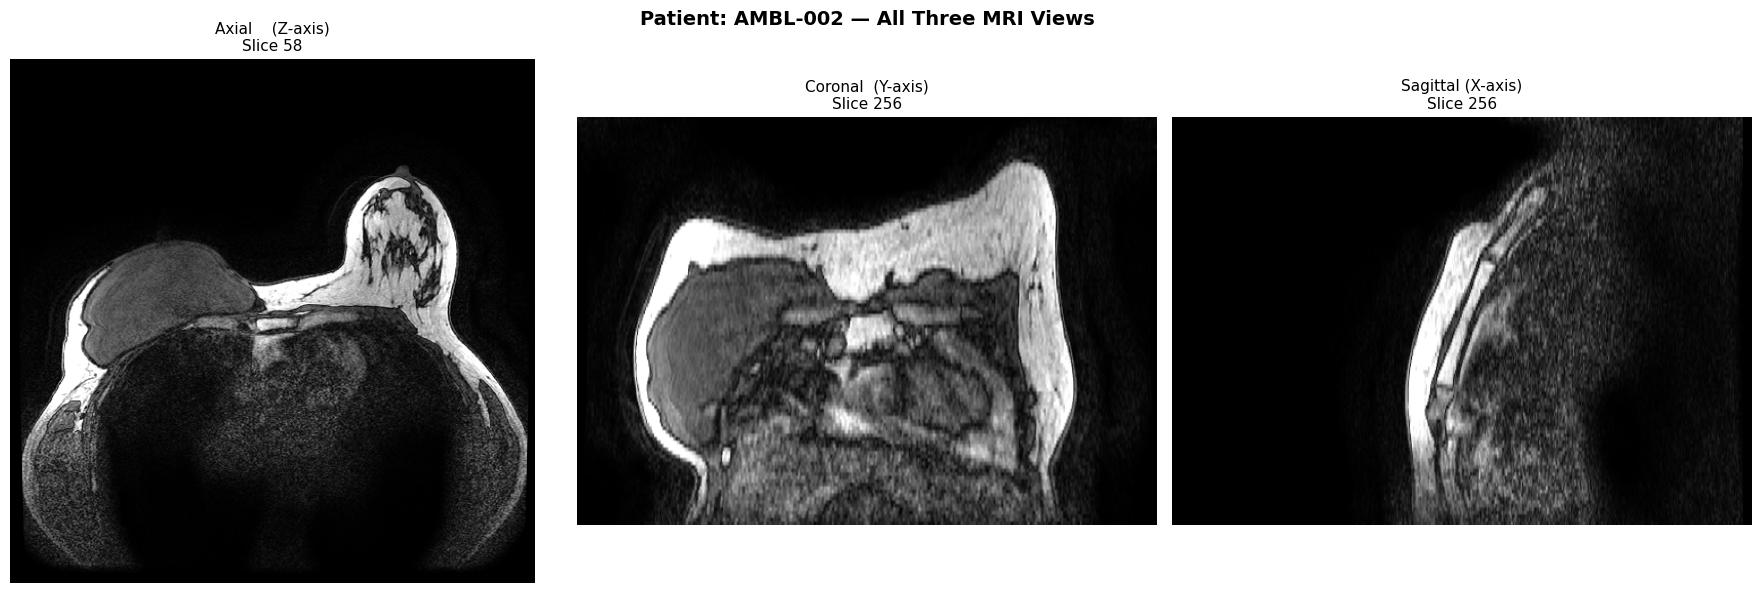


Showing axial overview ...


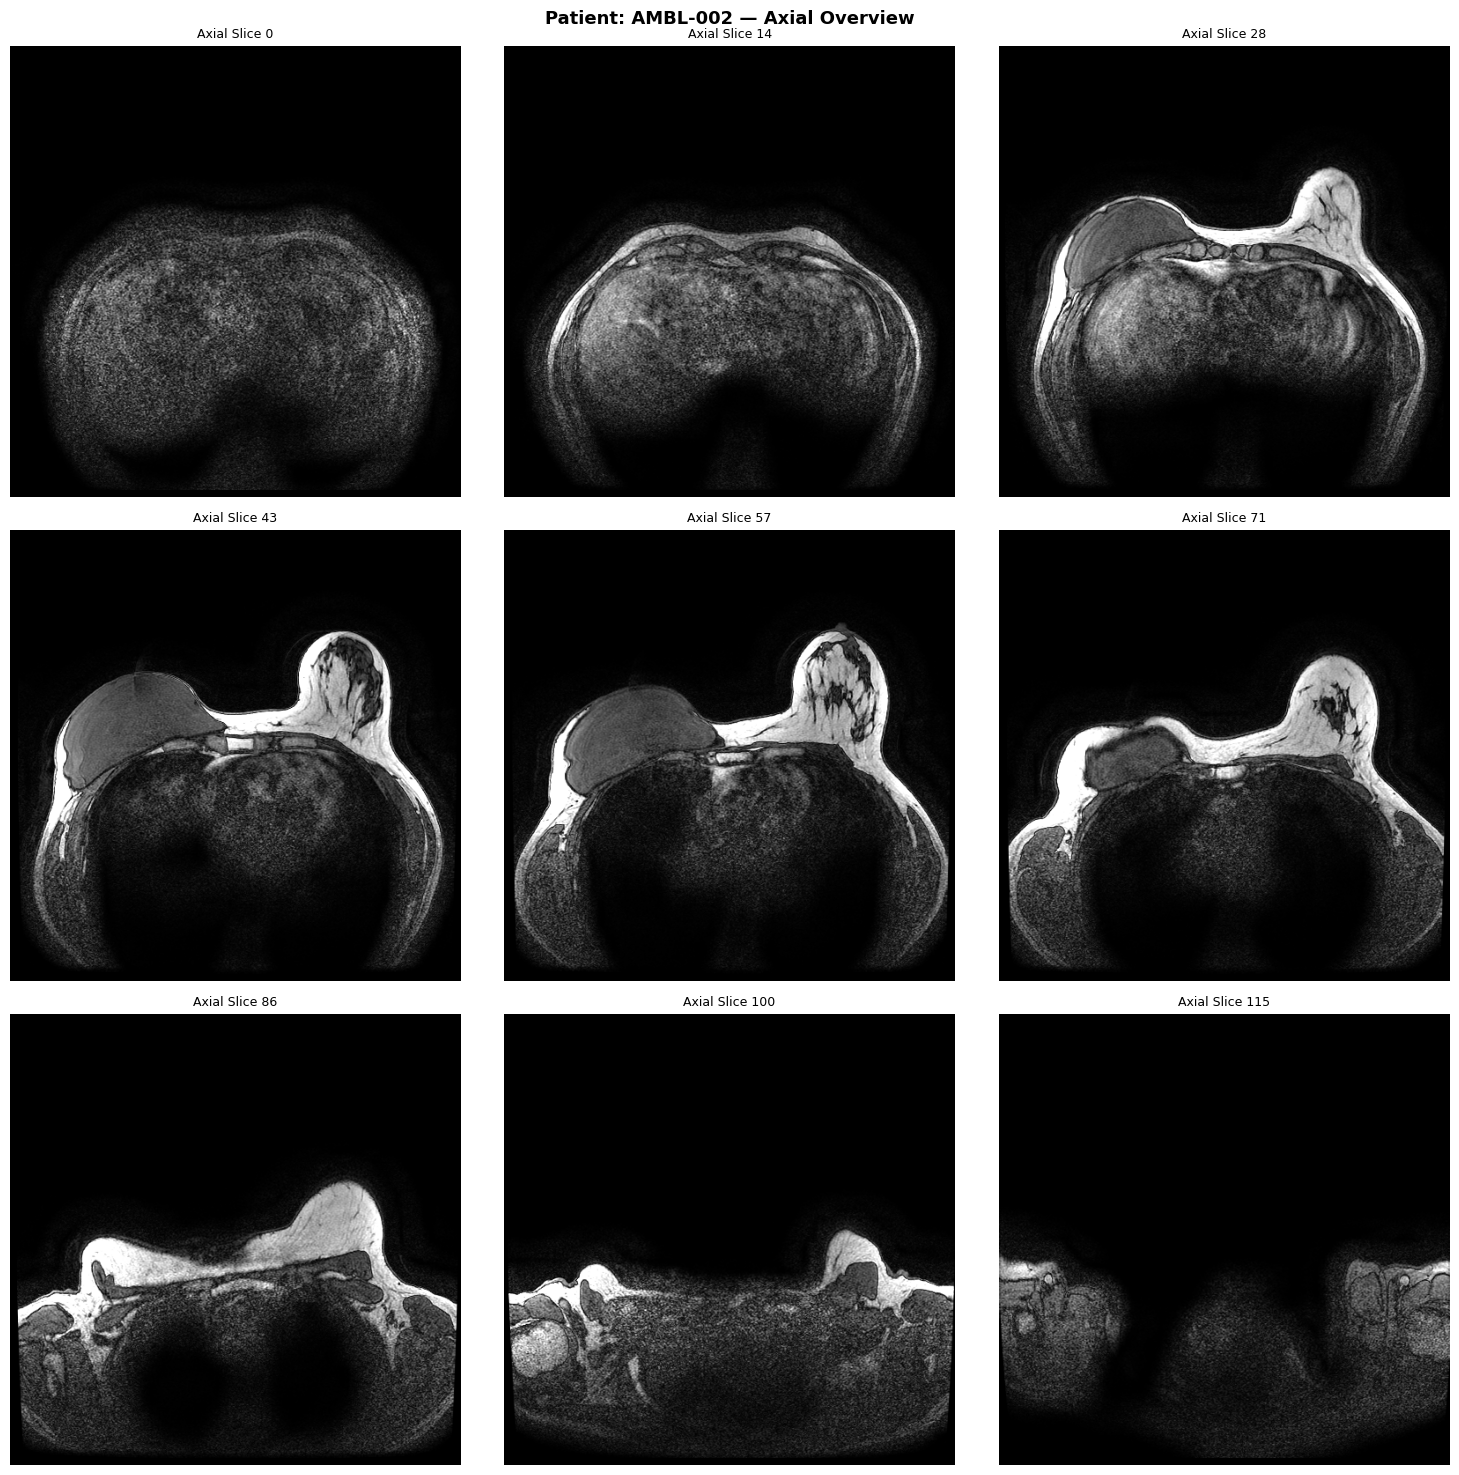


Showing coronal overview ...


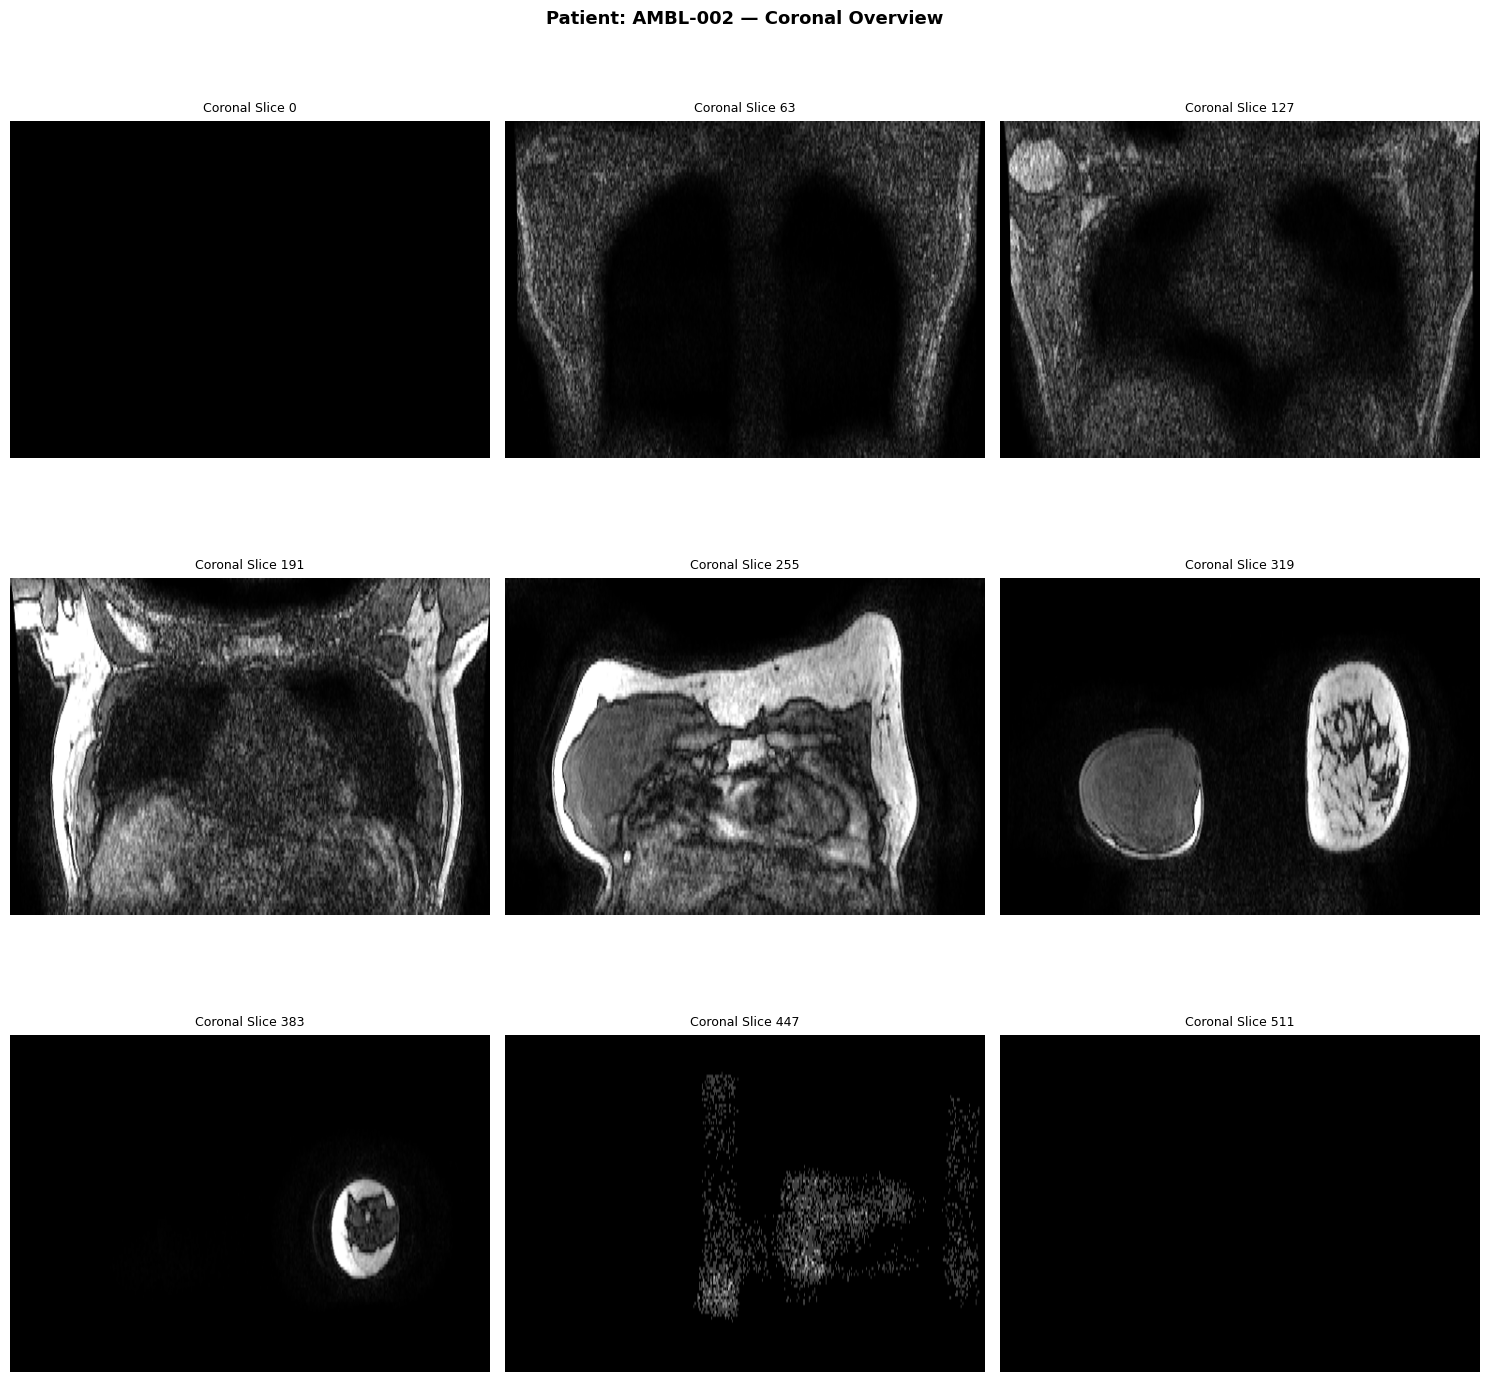


Showing sagittal overview ...


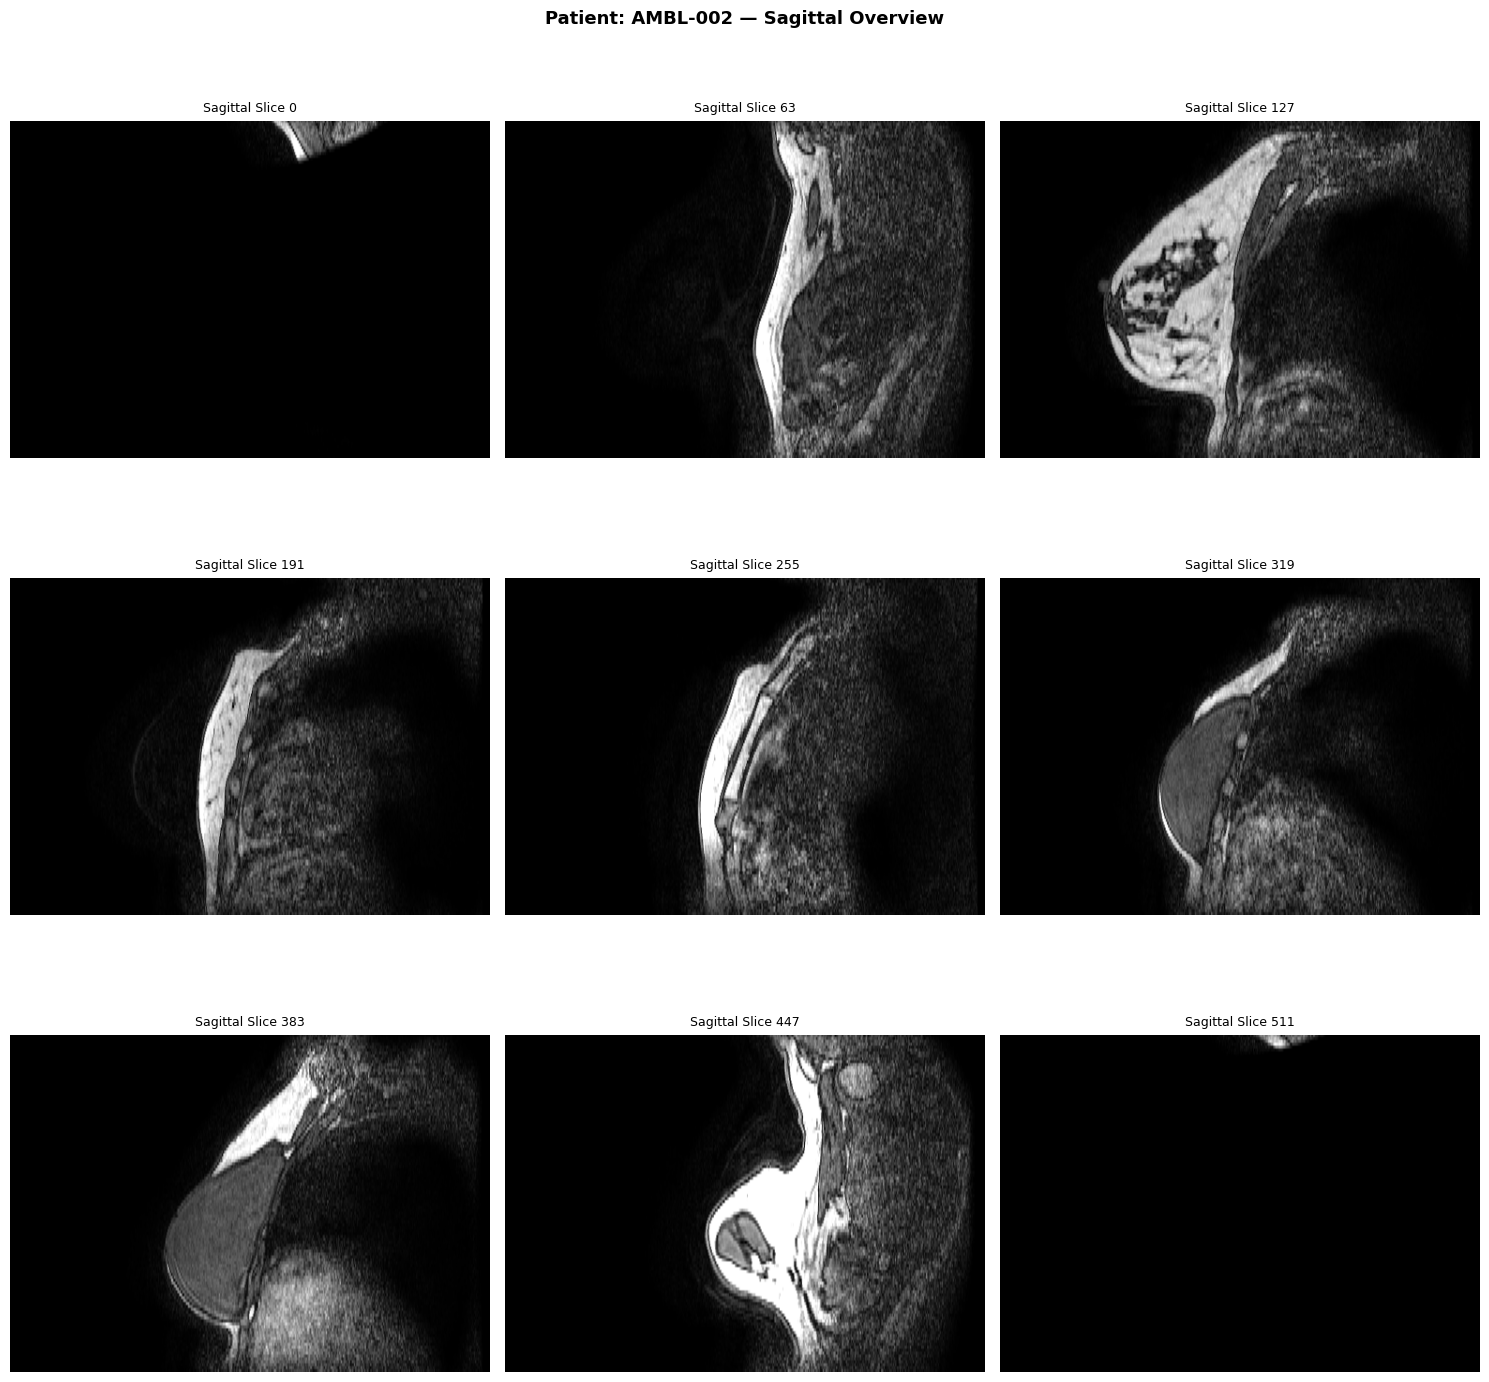


Test complete – no data was saved to disk.


In [ ]:
# =============================================================================
# STEP 1: Test Code – Load MRI Images in All Three Views & Verify
# =============================================================================

import os
import numpy as np
import pydicom
import matplotlib.pyplot as plt
from collections import defaultdict

# =============================================================================
# PATHS & CONFIGURATION
# =============================================================================

# Get the current working directory of the Jupyter Notebook
SCRIPT_DIR = os.getcwd()

# 1. External Large Data Path (Keep manual as the 600GB SSD moves between people - as of now, until data is fully processed)
DICOM_FOLDER = r"D:\Advanced-MRI-Breast-Lesions\DICOM Images\manifest-1713182663002\Advanced-MRI-Breast-Lesions"

EXCEL_PATH   = os.path.abspath(os.path.join(SCRIPT_DIR, "..", "Advanced-MRI-Breast-Lesions-DA-Clinical-Sep2024.xlsx"))
CACHE_DIR    = os.path.abspath(os.path.join(SCRIPT_DIR, "..", "data", "processed")) # later for saving the data - of no use right now
os.makedirs(CACHE_DIR, exist_ok=True)

#----------------------------------------------------------------------------------------

# Target search query for selecting the post-contrast axial sequence.
# Modified from "+C" to "C" to perfectly match specific folder namings.
# This was defined to later only show plots of this folder - if wanted can be changed to look at different images from the patient
TARGET_SERIES = "AX Sen Vibrant C"

# Read all patient directories from the root folder and sort them alphabetically
all_patients = sorted(os.listdir(DICOM_FOLDER))
TEST_PATIENT = all_patients[1]  # e.g. [0] selects the first patient in the folder (AMBL-001) for pipeline verification, can be changed if you want to look at different patients
print(f"Test patient: {TEST_PATIENT}")


# =============================================================================
# STEP 1: FIND AND GROUP DICOM FILES BY SCANNING SERIES
# =============================================================================

def find_image_dicoms(patient_id, dicom_folder):
    """
    Traverses the directory tree of a specific patient to collect all valid MRI image slices.
    Automatically filters out non-image data folders like annotations (ROI) or registrations (TRAM).
    """
    # Build absolute path to the targeted patient directory
    ppath = os.path.join(dicom_folder, patient_id)
    
    # Identify subdirectories inside the patient folder
    subs  = [os.path.join(ppath, d) for d in os.listdir(ppath)
             if os.path.isdir(os.path.join(ppath, d))]
    if not subs:
        return []

    # Manifest structures usually wrap datasets in a secondary parent folder
    patient_subfolder = subs[0]
    image_paths = []

    # Loop through individual scan sequence directories
    for d in os.listdir(patient_subfolder):
        # Ignore structural segmentations (ROI) or specialized map files (TRAM) -> for ROI this is only for now
        # But TRAM data will generally be fully ignored - is of no use for us
        if d.upper().startswith(("ROI", "TRAM")):
            continue
            
        sub = os.path.join(patient_subfolder, d)
        if os.path.isdir(sub):
            # Collect paths of files ending with .dcm (Standard DICOM format)
            image_paths += [
                os.path.join(sub, f) for f in os.listdir(sub)
                if f.lower().endswith(".dcm")
            ]
    return image_paths


def group_by_series(image_paths):
    """
    Reads DICOM metadata headers to group standalone slice files into cohesive 3D volumes.
    Detects dynamic MultiPhase series and separates individual temporal phases into unique keys.
    """
    # defaultdict automatically creates an empty list when encountering a new dictionary key
    series_dict = defaultdict(list)

    for path in image_paths:
        # Stop reading before the pixel data array to optimize execution speed (metadata only)
        ds = pydicom.dcmread(path, stop_before_pixels=True)
        
        # Slices require physical 3D spatial coordinates for volume stacking
        if not hasattr(ds, "ImagePositionPatient"):
            continue

        # Extract the absolute Z-axis physical coordinate of the slice
        z          = float(ds.ImagePositionPatient[2])
        series_num = getattr(ds, "SeriesNumber", 0)
        series_desc= getattr(ds, "SeriesDescription", "Unknown")

        # MultiPhase sequences store multiple timepoints within a single text description.
        # We query specific DICOM tags to isolate these steps into separate visual volumes.
        temporal   = getattr(ds, "TemporalPositionIdentifier", None)
        acq_num    = getattr(ds, "AcquisitionNumber", None)

        if temporal is not None:
            key = f"{series_num:04d} – {series_desc} [Phase {temporal}]"
        elif acq_num is not None and "MultiPhase" in series_desc:
            key = f"{series_num:04d} – {series_desc} [Acq {acq_num}]"
        else:
            key = f"{series_num:04d} – {series_desc}"

        # Append a tuple containing the sorting criteria (Z-coordinate) and the file path
        series_dict[key].append((z, path))

    # Crucial step: Sort the slices within every isolated series by their spatial Z coordinate.
    # This ensures that stacking the files yields a spatially continuous 3D volume.
    for key in series_dict:
        series_dict[key].sort(key=lambda x: x[0])

    return series_dict


def select_series(series_dict, target_desc=None):
    """
    Evaluates available series and automatically picks the optimal one for 3D processing.
    Filters by user-defined keyword and utilizes a statistical variance check on Z-spacing 
    to filter out sequences with jagged slice distributions or errors.
    """
    print("\nAvailable series:")
    print(f"  {'Series':<60} {'Slices':>8}   {'Z-spacing':>10}")
    print("  " + "-" * 82)

    candidates = []

    for key, slices in sorted(series_dict.items()):
        z_vals = [s[0] for s in slices]

        # Calculate spacing consistency by comparing the gap widths between subsequent slices
        if len(z_vals) > 1:
            diffs      = [abs(z_vals[i+1] - z_vals[i]) for i in range(len(z_vals)-1)]
            z_med      = float(np.median(diffs)) # The standard slice thickness
            z_std      = float(np.std(diffs))    # Variance in thickness across the file stack
            uniformity= z_std / (z_med + 1e-6)  # Closer to 0 means perfectly equidistant slices
        else:
            z_med, z_std, uniformity = 0, 0, 999

        print(f"  {key:<60} {len(slices):>8}   {z_med:>8.3f}mm  (std={z_std:.3f})")

        candidates.append({
            "key":        key,
            "slices":     slices,
            "count":      len(slices),
            "z_spacing":  z_med,
            "uniformity": uniformity,
        })

    # Strategy 1: Attempt to match the user's targeted keyword sequence
    if target_desc:
        matches = [c for c in candidates if target_desc.lower() in c["key"].lower()]
        if matches:
            # If multiple phases match, choose the one with the lowest spacing variance
            best = min(matches, key=lambda c: c["uniformity"])
            print(f"\n  → Selected (target match): '{best['key']}' "
                  f"({best['count']} slices, z={best['z_spacing']:.3f}mm)")
            return best["key"], best["slices"]

    # Strategy 2 Fallback: Find largest structural volume showing uniform slice distribution
    uniform = [c for c in candidates if c["uniformity"] < 0.1 and c["count"] > 50]
    if uniform:
        best = max(uniform, key=lambda c: c["count"])
    else:
        best = max(candidates, key=lambda c: c["count"])

    print(f"\n  → Selected (fallback): '{best['key']}' "
          f"({best['count']} slices, z={best['z_spacing']:.3f}mm)")
    return best["key"], best["slices"]


# =============================================================================
# STEP 2: LOAD TENSOR VOLUME AND INTENSITY NORMALIZATION
# =============================================================================

def load_volume_from_series(series_slices):
    """
    Loads raw pixel arrays into a single unified 3D NumPy array.
    Normalizes contrast intensity via percentile-clipping and calculates real spatial voxel sizes.
    """
    z_positions = [s[0] for s in series_slices]
    paths       = [s[1] for s in series_slices]

    # Read the baseline slice metadata to compute pixel spacing properties
    ds0         = pydicom.dcmread(paths[0])
    row_spacing = float(ds0.PixelSpacing[0]) if hasattr(ds0, "PixelSpacing") else 1.0
    col_spacing = float(ds0.PixelSpacing[1]) if hasattr(ds0, "PixelSpacing") else 1.0

    # Determine real physical slice thickness (Z-spacing) via coordinate diff medians
    if len(z_positions) > 1:
        diffs     = [abs(z_positions[i+1] - z_positions[i])
                     for i in range(len(z_positions) - 1)]
        z_spacing = float(np.median(diffs))
    else:
        z_spacing = 1.0

    # Safety boundary check: Replace invalid/zero values with a standard 1.0 multiplier
    z_spacing   = z_spacing   if (np.isfinite(z_spacing)   and z_spacing   > 0) else 1.0
    row_spacing = row_spacing if (np.isfinite(row_spacing) and row_spacing > 0) else 1.0
    col_spacing = col_spacing if (np.isfinite(col_spacing) and col_spacing > 0) else 1.0

    print(f"\n  Slices loaded:    {len(paths)}")
    print(f"  Z-spacing:        {z_spacing:.4f} mm")
    print(f"  Row spacing:      {row_spacing:.4f} mm")
    print(f"  Col spacing:      {col_spacing:.4f} mm")
    print(f"  Image size:       {ds0.pixel_array.shape}")

    # Load whole voxel matrix into memory as 32-bit floating point arrays
    pixel_arrays = [pydicom.dcmread(p).pixel_array.astype(np.float32) for p in paths]
    volume       = np.stack(pixel_arrays, axis=0) # Shapes resulting matrix into shape: (Z, H, W)

    # Intensity Normalization: 
    # High-intensity artifacts (sparks, fat tissues) stretch out the histogram. 
    # We clip the top 1% and bottom 1% to stabilize the contrast window before normalizing to [0, 1].
    p1, p99 = np.percentile(volume, 1), np.percentile(volume, 99)
    volume  = np.clip(volume, p1, p99)
    volume  = (volume - p1) / (p99 - p1 + 1e-6) # Added 1e-6 epsilon to protect against division-by-zero

    return volume, (z_spacing, row_spacing, col_spacing)


# =============================================================================
# STEP 3: AXIAL, CORONAL, AND SAGITTAL VIEW ALIGNMENT (MATCHING 3D SLICER)
# =============================================================================

def safe_aspect(num, den):
    """Prevents calculation errors if an acquisition parameter contains zero spacing."""
    if den == 0 or not np.isfinite(num / den):
        return 1.0
    r = num / den
    return r if r > 0 else 1.0


def get_three_views(volume, slice_idx=None):
    """
    Slices the 3D matrix array along its principal dimensions.
    Applies flips to correct raw file orientation to fit 3D Slicer coordinates (Prone breast MRI positioning).
    
    Orientation mapping rules applied below:
    - np.flipud: Flips image vertically to ensure 'Superior' body direction stays on top.
    - np.fliplr: Flips image horizontally to swap Left/Right viewports to mirror 3D Slicer exactly.
    """
    Z, H, W = volume.shape
    # Default to the absolute center slice of the volume matrix if no exact slice is requested
    z_mid = Z // 2 if slice_idx is None else min(slice_idx, Z - 1)
    y_mid = H // 2
    x_mid = W // 2

    # 1. AXIAL VIEW: Slice horizontally. Apply both vertical and horizontal mirrors. To ensure exact comparison to 3D-Slicer
    axial = np.fliplr(np.flipud(volume[z_mid, :, :]))

    # 2. CORONAL VIEW: Slice front-to-back. Mirror vertically and horizontally.
    coronal = np.fliplr(np.flipud(volume[:, y_mid, :]))

    # 3. SAGITTAL VIEW: Slice side-to-side. Already perfectly aligned via original fliplr/flipud logic.
    sagittal = np.fliplr(np.flipud(volume[:, :, x_mid]))

    return {
        "axial":    (axial,    z_mid, "Axial    (Z-axis)"),
        "coronal":  (coronal,  y_mid, "Coronal  (Y-axis)"),
        "sagittal": (sagittal, x_mid, "Sagittal (X-axis)"),
    }


# =============================================================================
# STEP 4: MATPLOTLIB RENDER ENGINE
# =============================================================================

def visualize_three_views(views, patient_id, spacing):
    """Plots a 1x3 overview window containing the core cross-sections."""
    z_sp, r_sp, c_sp = spacing
    
    # Calculate aspect ratio adjustments to rectify anisotropic voxels (unequal slice thicknesses)
    aspect_ratios = {
        "axial":    safe_aspect(r_sp, c_sp),
        "coronal":  safe_aspect(z_sp, c_sp),
        "sagittal": safe_aspect(z_sp, r_sp),
    }

    print(f"  Aspect ratios → axial: {aspect_ratios['axial']:.3f} | "
          f"coronal: {aspect_ratios['coronal']:.3f} | "
          f"sagittal: {aspect_ratios['sagittal']:.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Patient: {patient_id} — All Three MRI Views",
                 fontsize=14, fontweight="bold")

    for ax, (key, (img, idx, title)) in zip(axes, views.items()):
        ax.imshow(img, cmap="gray", aspect=aspect_ratios[key])
        ax.set_title(f"{title}\nSlice {idx}", fontsize=11)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def visualize_multiple_slices(volume, spacing, view="axial", n_slices=9):
    """
    Generates a 3x3 sequential slice matrix layout.
    Invaluable for inspecting full lesion dimensions or scanning for spatial artifacts.
    """
    Z, H, W          = volume.shape
    z_sp, r_sp, c_sp = spacing

    # Extract equidistant index points throughout the depth profile of chosen viewport
    if view == "axial":
        indices = np.linspace(0, Z - 1, n_slices, dtype=int)
        # Added np.fliplr inside list comprehension to guarantee proper Slicer L/R layout
        imgs    = [np.fliplr(np.flipud(volume[i, :, :])) for i in indices]
        aspect  = safe_aspect(r_sp, c_sp)
        label   = "Axial Slice"
    elif view == "coronal":
        indices = np.linspace(0, H - 1, n_slices, dtype=int)
        # Added np.fliplr inside list comprehension to guarantee proper Slicer L/R layout
        imgs    = [np.fliplr(np.flipud(volume[:, i, :])) for i in indices]
        aspect  = safe_aspect(z_sp, c_sp)
        label   = "Coronal Slice"
    elif view == "sagittal":
        indices = np.linspace(0, W - 1, n_slices, dtype=int)
        imgs    = [np.fliplr(np.flipud(volume[:, :, i])) for i in indices]
        aspect  = safe_aspect(z_sp, r_sp)
        label   = "Sagittal Slice"

    cols  = 3
    rows  = (n_slices + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
    axes  = axes.flatten()

    for i, (img, idx) in enumerate(zip(imgs, indices)):
        axes[i].imshow(img, cmap="gray", aspect=aspect)
        axes[i].set_title(f"{label} {idx}", fontsize=9)
        axes[i].axis("off")

    # Disable visibility for leftover placeholder subplots in the layout grid
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Patient: {TEST_PATIENT} — {view.capitalize()} Overview",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


# =============================================================================
# MAIN EXECUTION ENTRY POINT
# =============================================================================
if __name__ == "__main__":
    print("=" * 60)
    print(f"Loading patient: {TEST_PATIENT}")
    print("=" * 60)

    # 1. Harvest target image paths
    image_paths = find_image_dicoms(TEST_PATIENT, DICOM_FOLDER)
    print(f"\nTotal DICOM files found: {len(image_paths)}")

    if len(image_paths) == 0:
        print("ERROR: No DICOM files found. Please check the path.")
    else:
        # 2. Re-organize slice soup into sorted sequence dictionaries
        print("\nGrouping by series ...")
        series_dict = group_by_series(image_paths)

        # 3. Dynamically evaluate and select the best imaging sequence
        best_key, best_series = select_series(series_dict, target_desc=TARGET_SERIES)

        # 4. Construct the normalized 3D tensor and load its spatial coordinate spacings
        print("\nLoading volume ...")
        volume, spacing = load_volume_from_series(best_series)
        print(f"\nVolume shape: {volume.shape}  (Z, H, W)")
        print(f"Value range:  [{volume.min():.3f}, {volume.max():.3f}]")

        # 5. Extracts properly rotated views matching 3D Slicer
        views = get_three_views(volume)

        # 6. Trigger plotting pipelines
        print("\nShowing all three views ...")
        visualize_three_views(views, TEST_PATIENT, spacing)

        print("\nShowing axial overview ...")
        visualize_multiple_slices(volume, spacing, view="axial", n_slices=9)

        print("\nShowing coronal overview ...")
        visualize_multiple_slices(volume, spacing, view="coronal", n_slices=9)

        print("\nShowing sagittal overview ...")
        visualize_multiple_slices(volume, spacing, view="sagittal", n_slices=9)

        print("\n" + "=" * 60)
        print("Test complete – no data was saved to disk.")
        print("=" * 60)